# Desarrollo del modelo XGBoost
---

# Configuración de ambiente

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler

import lightgbm as lgb

# Carga de modulos_apex
from modulos_apex_dev import BTC_DataExtractor as btc_etl
from modulos_apex_dev import trading_backtester as tbt

import os
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

CURRENT_DIR = os.getcwd()

# Carga de datos y variables
---


In [2]:
CURRENT_DIR

'/Users/julesaccm/Documents/Repos/Apex-project/notebooks'

In [3]:
# Cargamos los datos desde la carpeta data y si no existen, ejecutamos el pipeline
try: 
    os.chdir('..')
    os.chdir('data/processed')
    df_final = pd.read_csv('btc_data.csv', index_col=0)
    print("Datos cargados desde 'data/processed/btc_data.csv'")

except FileNotFoundError:
    print("Archivo no encontrado. Ejecutando el pipeline para generar los datos...")

    # 1. Instanciar la clase (Configuramos las variables globales del proceso)
    extractor = btc_etl.BTC_DataExtractor(
        fecha_inicio="2024-01-01", 
        fecha_fin="2026-01-01", 
        ventana_critica=5
    )

    # 2. Ejecutar las transformaciones en cadena (Pipeline)
    # Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

    # Paso A: Obtener el precio histórico y volumen
    df_base = extractor.obtener_datos_btc()

    # Paso B: Etiquetar máximos y mínimos (Nuestro Target)
    df_etiquetado = extractor.etiquetar_puntos_criticos(df_base)

    # Paso C: Calcular todo el análisis técnico
    df_con_indicadores = extractor.agregar_indicadores_avanzados(df_etiquetado)

    # Paso D: Enriquecer con datos macroeconómicos
    df_final = extractor.agregar_contexto_macro(df_con_indicadores)

    # 3. Revisar el resultado final
    print("\n--- Vista previa de las primeras 5 filas ---")
    print(df_final.head())

    # Creamos el archivo en la carpeta data/processed
    os.chdir(CURRENT_DIR)
    os.chdir('..')
    os.makedirs('data/processed', exist_ok=True)
    df_final.to_csv('data/processed/btc_data.csv', index=True)
    
    print("Datos generados y guardados en 'data/processed/btc_data.csv'")

finally:
    os.chdir(CURRENT_DIR) 


Datos cargados desde 'data/processed/btc_data.csv'


In [4]:
df_final.head()

,Open,High,Low,Close,Volume,Retorno_Log,Target,RSI_14,BBL_20_2.0_2.0,BBM_20_2.0_2.0,...,ROC_10,BULLP_13,BEARP_13,UO_7_14_28,SP500_Close,DXY_Close,Oro_Close,SP500_Retorno,DXY_Retorno,Oro_Retorno
Date,,,,,,,,,,,,,,,,,,,,,
2024-02-04,42994.941406,43097.644531,42374.832031,42583.582031,14802225490,-0.009551,0,55.156994,39455.992843,41899.333984,...,6.635414,619.166722,-103.645778,54.454136,4942.810059,104.449997,2025.699951,0.000000,0.000000,0.000000
2024-02-05,42577.621094,43494.250000,42264.816406,42658.667969,18715487317,0.001762,0,55.579270,39475.186244,41874.520117,...,2.013056,990.030739,-239.402854,47.903907,4942.810059,104.449997,2025.699951,0.000000,0.000000,0.000000
2024-02-06,42657.390625,43344.148438,42529.019531,43084.671875,16798476726,0.009937,0,57.996020,39461.555932,41891.621094,...,2.290161,757.007375,-58.121531,51.256441,4954.229980,104.180000,2034.500000,0.002310,-0.002585,0.004344
2024-02-07,43090.019531,44341.949219,42775.957031,44318.222656,21126587775,0.028229,0,64.088663,39405.656914,42044.429297,...,5.430229,1507.510786,-58.481402,62.110142,4995.060059,104.040001,2035.199951,0.008241,-0.001344,0.000344
2024-02-08,44332.125000,45575.839844,44332.125000,45301.566406,26154524080,0.021946,0,68.065262,39225.992581,42228.587305,...,4.650963,2388.954557,1145.239714,61.831010,4997.910156,104.150002,2032.199951,0.000571,0.001057,-0.001474


# Preparación de datos de entrenamiento y evaluación para el modelo
---

In [5]:
# --- 1. CONFIGURACIÓN DE FEATURES ---
df_apex = df_final.copy()

# Excluimos los precios crudos de BTC, el Target y los precios crudos macroeconómicos
columnas_excluir = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Target',
    'SP500_Close', 'DXY_Close', 'Oro_Close' # ¡Importante! Solo queremos sus retornos
    , 'Retorno_Log'
]

# Creamos la lista final de features (X)
features = [col for col in df_apex.columns if col not in columnas_excluir]

# --- 2. PREPARACIÓN DE DATOS (Train / Test) ---
X = df_apex[features]
y = df_apex['Target']

# División cronológica (80% Train, 20% Test)
split_idx = int(len(df_apex) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Entrenando con {len(features)} variables (Técnicas + Macro)...")
print(f"Días de entrenamiento: {len(X_train)} | Días de prueba: {len(X_test)}")

# Traducir las etiquetas (-1, 0, 1) a formato XGBoost (0, 1, 2)
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

Entrenando con 30 variables (Técnicas + Macro)...
Días de entrenamiento: 557 | Días de prueba: 140


In [6]:
# 5. Recuperamos la porción de "Test" pero del DataFrame original (que SÍ tiene 'Close')
split_idx = int(len(df_apex) * 0.8)
df_test_completo = df_apex.iloc[split_idx:].copy()


# Selección de variables
---

La selección de las variables se empleará sobre el conjunto completo de datos.

## Análisis de correlación

In [7]:
df_apex[features].describe().T

,count,mean,std,min,25%,50%,75%,max
RSI_14,697.0,53.102883,12.464846,23.086270,44.360442,51.692738,61.554143,87.624900
BBL_20_2.0_2.0,697.0,78614.216629,20991.506644,38456.090575,59212.073977,80296.720042,97404.606206,116638.320452
BBM_20_2.0_2.0,697.0,85150.351730,21149.051269,41874.520117,64798.300391,88529.880078,104705.298438,118311.751953
BBU_20_2.0_2.0,697.0,91686.486831,21707.721029,44273.853991,71230.893970,94576.037559,110306.270961,128417.662570
BBB_20_2.0_2.0,697.0,16.143020,7.944923,2.828851,10.418694,14.493770,18.655160,47.025534
BBP_20_2.0_2.0,697.0,0.527829,0.321032,-0.402861,0.289134,0.534246,0.788883,1.298497
Retorno_1d,697.0,0.001332,0.025092,-0.086820,-0.012312,0.000384,0.013052,0.121443
Volumen_Relativo,697.0,1.019104,0.424557,0.255073,0.731131,0.977590,1.227257,3.256822
STOCHk_9_6_3,697.0,55.985774,25.591064,6.005778,33.210133,57.790072,81.119022,96.646430
STOCHd_9_6_3,697.0,56.154377,22.081300,10.802746,37.544950,57.510548,73.868286,94.059776


In [8]:
scaler = StandardScaler()
features_df_std = pd.DataFrame(scaler.fit_transform(df_apex[features]), columns=features, index=df_apex.index)
features_df_std.describe().T

,count,mean,std,min,25%,50%,75%,max
RSI_14,697.0,-8.155440e-17,1.000718,-2.409831,-0.701871,-0.113211,0.678494,2.771539
BBL_20_2.0_2.0,697.0,4.077720e-16,1.000718,-1.914439,-0.924949,0.080209,0.895785,1.812705
BBM_20_2.0_2.0,697.0,8.155440e-17,1.000718,-2.047700,-0.963006,0.159910,0.925289,1.569111
BBU_20_2.0_2.0,697.0,-1.631088e-16,1.000718,-2.185705,-0.942995,0.133207,0.858365,1.693294
BBB_20_2.0_2.0,697.0,6.116580e-17,1.000718,-1.677012,-0.721019,-0.207734,0.316421,3.889867
BBP_20_2.0_2.0,697.0,-9.174870e-17,1.000718,-2.901140,-0.744059,0.020002,0.813753,2.402319
Retorno_1d,697.0,1.019430e-17,1.000718,-3.515694,-0.544160,-0.037833,0.467406,4.790231
Volumen_Relativo,697.0,-8.155440e-17,1.000718,-1.800889,-0.678778,-0.097851,0.490635,5.274501
STOCHk_9_6_3,697.0,1.733031e-16,1.000718,-1.954428,-0.890623,0.070556,0.982816,1.590002
STOCHd_9_6_3,697.0,3.568005e-16,1.000718,-2.055323,-0.843374,0.061461,0.802789,1.717862


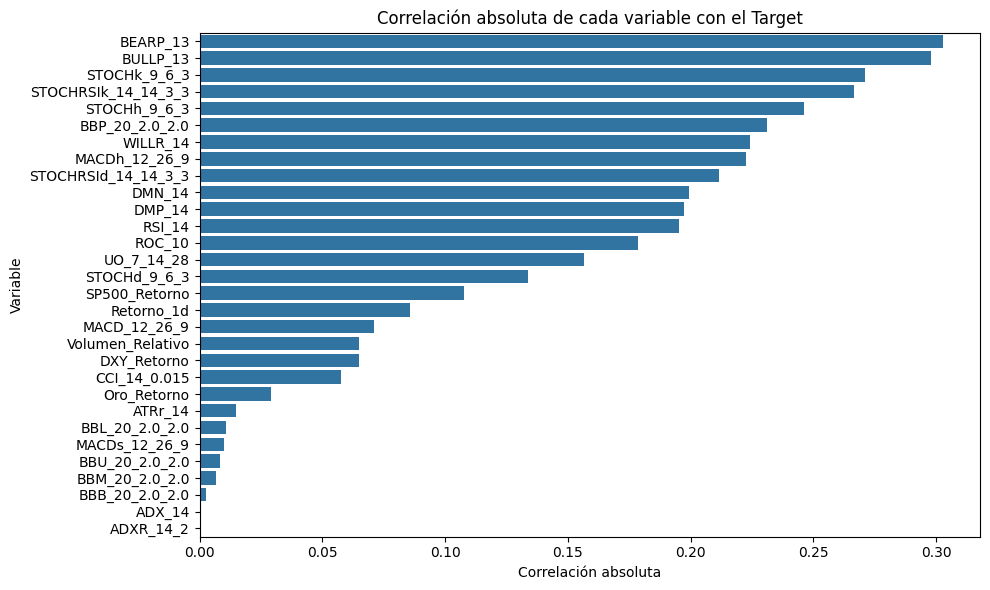

In [9]:
feature_corr = features_df_std.corrwith(df_apex['Target'], method='spearman')
sort_corr = feature_corr.abs().sort_values(ascending=False).to_frame().reset_index()
sort_corr.columns = ['Variable', 'Correlación']

plt.figure(figsize=(10, 6))
sns.barplot(x='Correlación', y='Variable', data=sort_corr)
plt.title('Correlación absoluta de cada variable con el Target')
plt.xlabel('Correlación absoluta')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


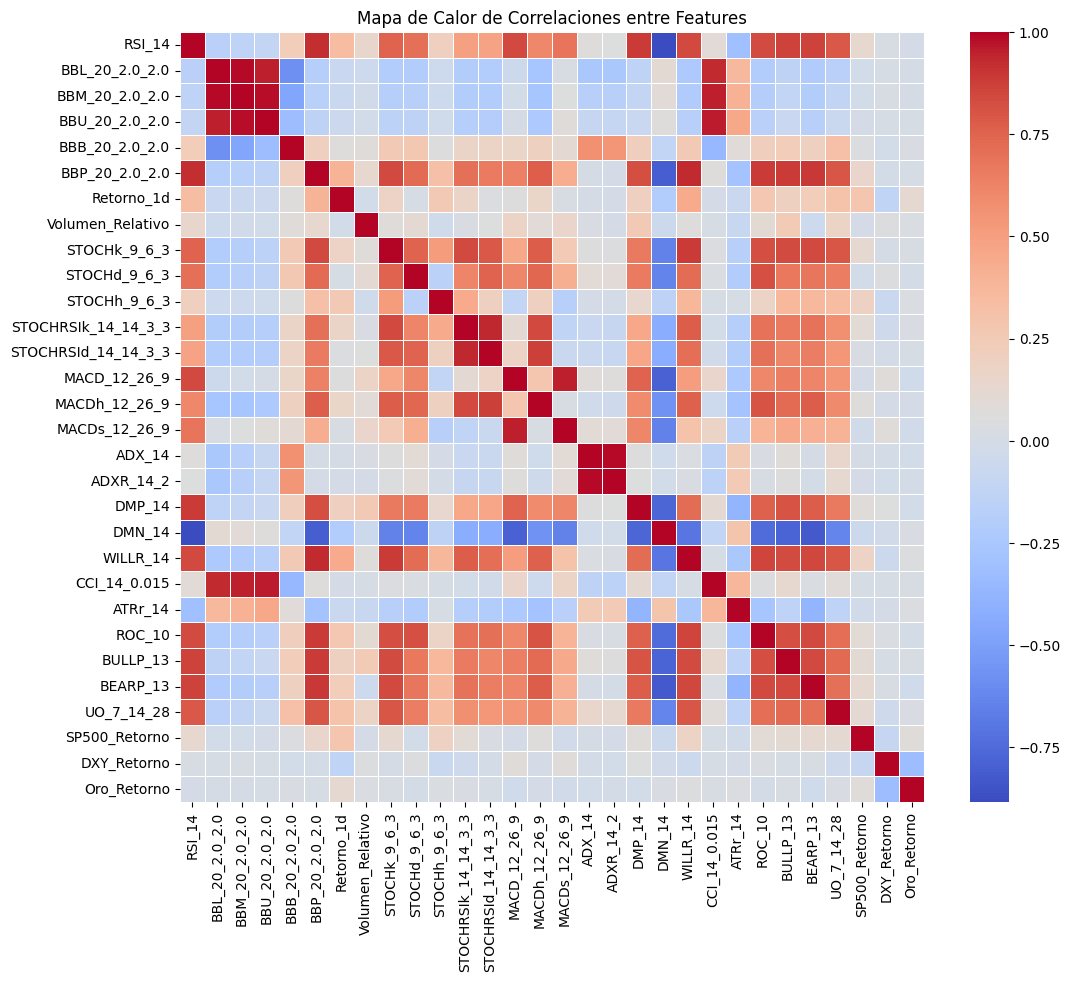

In [10]:
# Correlación entre variables
plt.figure(figsize=(12, 10))
sns.heatmap(features_df_std.corr('spearman'), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones entre Features")
plt.show()

In [11]:
# Top 15 variables más correlacionadas con el Target
target_top15_corr = sort_corr.head(15)['Variable'].tolist()
print(f"TOP 15 variables más correlacionadas con el Target: \n{target_top15_corr}")

TOP 15 variables más correlacionadas con el Target: 
['BEARP_13', 'BULLP_13', 'STOCHk_9_6_3', 'STOCHRSIk_14_14_3_3', 'STOCHh_9_6_3', 'BBP_20_2.0_2.0', 'WILLR_14', 'MACDh_12_26_9', 'STOCHRSId_14_14_3_3', 'DMN_14', 'DMP_14', 'RSI_14', 'ROC_10', 'UO_7_14_28', 'STOCHd_9_6_3']


In [16]:
from modulos_apex_dev.correlated_vars_selector import highly_correlated_vars as hcv

In [17]:
# Dataframe con las variables más correlacionadas con otras variables (Posibles redundancias)
feature_corr_matrix = features_df_std.corr('spearman').abs()

pares_feature = []
# Tomamos solo la parte superior de la matriz de correlacion para evitar duplicados (i,j) y (j,i)
for i in range(len(features)):
    for j in range(i+1, len(features)):
        if feature_corr_matrix.iloc[i, j] > 0.7:
            pares_feature.append((features[i], features[j], feature_corr_matrix.iloc[i, j]))

pares_feature_df = pd.DataFrame(pares_feature, columns=['Variable_1', 'Variable_2', 'Correlacion_mayor_0.7'])
pares_feature_df = pares_feature_df.merge(
    sort_corr,
    left_on='Variable_2',
    right_on='Variable',
    how='left'
).drop(columns=['Variable']).rename(columns={'Correlación':'corr_var2_target'}) \
.merge(
    sort_corr,
    left_on='Variable_1',
    right_on='Variable',
    how='left'
).drop(columns=['Variable']).rename(columns={'Correlación':'corr_var1_target'}) \
    .sort_values(by=['Variable_1','corr_var2_target'], ascending=[True, False])

pares_feature_df['rank'] = pares_feature_df.groupby(['Variable_1'])['corr_var2_target'].rank(method='first', ascending=False)

# pares_feature_df['flag_test'] = np.where(
#     (pares_feature_df['corr_var1_target']<=pares_feature_df['corr_var2_target'])
#     & (pares_feature_df['rank']==1),
#     pares_feature_df['Variable_2'],
#     pares_feature_df['Variable_1'])

print(pares_feature_df)

features_redundantes = set(pares_feature_df['Variable_1'].unique()).union(set(pares_feature_df['Variable_2'].unique()))
print(f"Variables potencialmente redundantes (correlación > 0.7): {len(features_redundantes)}\n{features_redundantes}")

features_no_redundantes = [feat for feat in features if feat not in features_redundantes]
print(f"\nVariables no redundantes (correlación <= 0.7): {len(features_no_redundantes)}\n{features_no_redundantes}")


        Variable_1      Variable_2  Correlacion_mayor_0.7  corr_var2_target  \
54          ADX_14       ADXR_14_2               0.991657          0.000022   
13  BBL_20_2.0_2.0    CCI_14_0.015               0.927992          0.057487   
12  BBL_20_2.0_2.0  BBU_20_2.0_2.0               0.949850          0.008393   
11  BBL_20_2.0_2.0  BBM_20_2.0_2.0               0.988025          0.006893   
15  BBM_20_2.0_2.0    CCI_14_0.015               0.952385          0.057487   
..             ...             ...                    ...               ...   
28    STOCHk_9_6_3    STOCHd_9_6_3               0.749937          0.133714   
66        WILLR_14        BEARP_13               0.852493          0.302785   
65        WILLR_14        BULLP_13               0.833062          0.298095   
64        WILLR_14          ROC_10               0.859462          0.178597   
67        WILLR_14      UO_7_14_28               0.800269          0.156559   

    corr_var1_target  rank  
54          0.000694  

In [18]:
high_corr_vars = hcv(features_df_std, sort_corr, 'Correlación', 0.7)

Seleccion por criterio externo: iteración 29
Seleccion por criterio externo: iteración 28
Seleccion por criterio externo: iteración 27
Seleccion por criterio externo: iteración 26
Seleccion por criterio externo: iteración 25
Seleccion por criterio externo: iteración 24
Seleccion por criterio externo: iteración 23
Seleccion por criterio externo: iteración 22
Seleccion por criterio externo: iteración 21
Seleccion por criterio externo: iteración 20
Seleccion por criterio externo: iteración 19
Seleccion por criterio externo: iteración 18
Seleccion por criterio externo: iteración 17
Seleccion por criterio externo: iteración 16
Seleccion por criterio externo: iteración 15
Seleccion por criterio externo: iteración 14
Seleccion por criterio externo: iteración 13
Proceso finalizado.


In [21]:
high_target_corr_no_redundant = [var for var in features if var not in high_corr_vars]

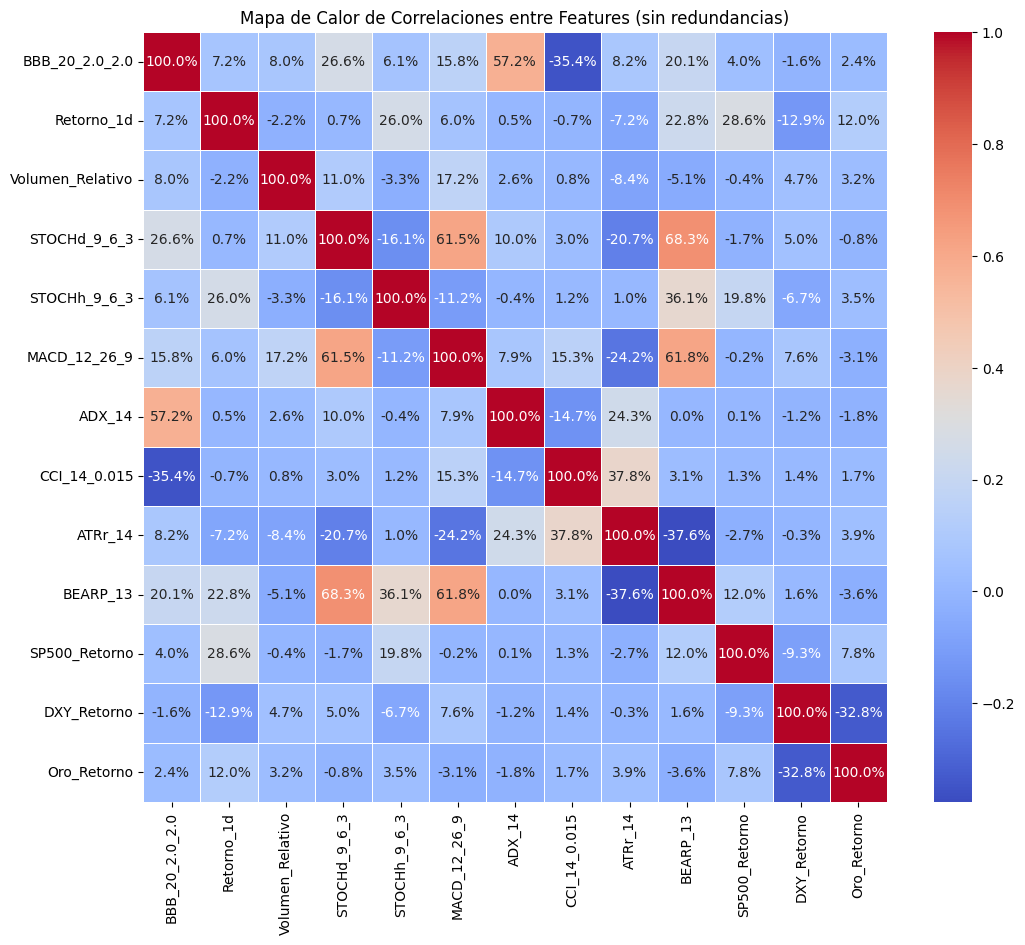

In [39]:
# Correlación entre variables depurando las redundantes
plt.figure(figsize=(12, 10))
sns.heatmap(features_df_std[high_target_corr_no_redundant].corr('spearman'), annot=True, fmt=".1%", cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones entre Features (sin redundancias)")
plt.show()

Para la selección de variables se tienen dos propuestas:
1. Una propuesta es considerar, de las variables potencialmente redundantes, la de mayor correlación con la variable objetivo.

2. Otra propuesta es evaluar las variables no redundantes e ir probando el backtesting de las redundantes una por una y seleccionar el conjunto con mejor retorno.

## Definición de algoritmo de selección

In [29]:
def feature_selection_algorithm(
        features_list: list, 
        X_train, y_train_xgb, 
        X_test, y_test_xgb) -> pd.DataFrame:
    """
    Algoritmo de selección de variables.

    El objetivo de esta función entrenar un modelo XGBoost con cada una de 
    las variables _features_list_ para obtener su importancia (gain).

    Args:
        features_list (list): Lista con las variables.
        X_train (DataFrame): Conjunto de entrenamiento con las variables.
        y_train_xgb (array): Etiquetas de entrenamiento codificadas para XGBoost.
        X_test (DataFrame): Conjunto de prueba con las variables.
        y_test_xgb (array): Etiquetas de prueba codificadas para XGBoost

    Returns:
        DataFrame con las variables y su importancia (gain).
    """
    # 1. Librerias necesarias
    import xgboost as xgb
    import numpy as np

    # 2. Inicialización del modelo
    modelo_tuning = xgb.XGBClassifier(
        max_depth=5,
        learning_rate=0.005,
        subsample=0.7,
        gamma=0.117266,
        n_estimators=100,
        scale_pos_weight=4.15615,
        early_stopping_rounds=50, # Tu recomendación aplicada
        random_state=42,
        n_jobs=-1
    )
            
    _resultados = []
    
    for f in features_list:
        print(f"Evaluando variable: {f}")

        # Entrenamos pasándole el conjunto de prueba para el Early Stopping
        modelo_tuning.fit(
            X_train[[f]], y_train_xgb,
            eval_set=[(X_test[[f]], y_test_xgb)],
            verbose=False
        )

        # Obtenemos la importancia de la varibale f
        importancia_f = modelo_tuning.get_booster().get_score(importance_type='gain').get(f,0)

        _resultados.append((f, importancia_f))

    # Consolidamos los resultados en un DataFrame    
    _df_resultados = pd.DataFrame(_resultados, columns=['variable','importancia_gain'])
    _df_resultados = _df_resultados.sort_values(by='importancia_gain', ascending=False).reset_index(drop=True)

    return _df_resultados


In [31]:
# Ejecución del algoritmo de selección de variables

features_importance = feature_selection_algorithm(
    features_list=features,
    X_train=X_train, y_train_xgb=y_train_xgb,
    X_test=X_test, y_test_xgb=y_test_xgb,
    )
    

Evaluando variable: RSI_14
Evaluando variable: BBL_20_2.0_2.0
Evaluando variable: BBM_20_2.0_2.0
Evaluando variable: BBU_20_2.0_2.0
Evaluando variable: BBB_20_2.0_2.0
Evaluando variable: BBP_20_2.0_2.0
Evaluando variable: Retorno_1d
Evaluando variable: Volumen_Relativo
Evaluando variable: STOCHk_9_6_3
Evaluando variable: STOCHd_9_6_3
Evaluando variable: STOCHh_9_6_3
Evaluando variable: STOCHRSIk_14_14_3_3
Evaluando variable: STOCHRSId_14_14_3_3
Evaluando variable: MACD_12_26_9
Evaluando variable: MACDh_12_26_9
Evaluando variable: MACDs_12_26_9
Evaluando variable: ADX_14
Evaluando variable: ADXR_14_2
Evaluando variable: DMP_14
Evaluando variable: DMN_14
Evaluando variable: WILLR_14
Evaluando variable: CCI_14_0.015
Evaluando variable: ATRr_14
Evaluando variable: ROC_10
Evaluando variable: BULLP_13
Evaluando variable: BEARP_13
Evaluando variable: UO_7_14_28
Evaluando variable: SP500_Retorno
Evaluando variable: DXY_Retorno
Evaluando variable: Oro_Retorno


In [32]:
features_importance

,variable,importancia_gain
0,BEARP_13,1.380556
1,BULLP_13,1.051795
2,Volumen_Relativo,1.050382
3,DMN_14,0.989078
4,STOCHRSIk_14_14_3_3,0.959340
5,STOCHh_9_6_3,0.934704
6,RSI_14,0.914316
7,Oro_Retorno,0.868837
8,DXY_Retorno,0.863555
9,BBP_20_2.0_2.0,0.863071


In [35]:
high_corr_vars_gain = hcv(features_df_std, features_importance.rename(columns={'variable':'Variable'}, inplace=True), 'importancia_gain', 0.7)
high_gain_no_redundant = [var for var in features if var not in high_corr_vars_gain]

Seleccion por correlacion media: iteración 29
Seleccion por correlacion media: iteración 28
Seleccion por correlacion media: iteración 27
Seleccion por correlacion media: iteración 26
Seleccion por correlacion media: iteración 25
Seleccion por correlacion media: iteración 24
Seleccion por correlacion media: iteración 23
Seleccion por correlacion media: iteración 22
Seleccion por correlacion media: iteración 21
Seleccion por correlacion media: iteración 20
Seleccion por correlacion media: iteración 19
Seleccion por correlacion media: iteración 18
Seleccion por correlacion media: iteración 17
Seleccion por correlacion media: iteración 16
Seleccion por correlacion media: iteración 15
Seleccion por correlacion media: iteración 14
Proceso finalizado.


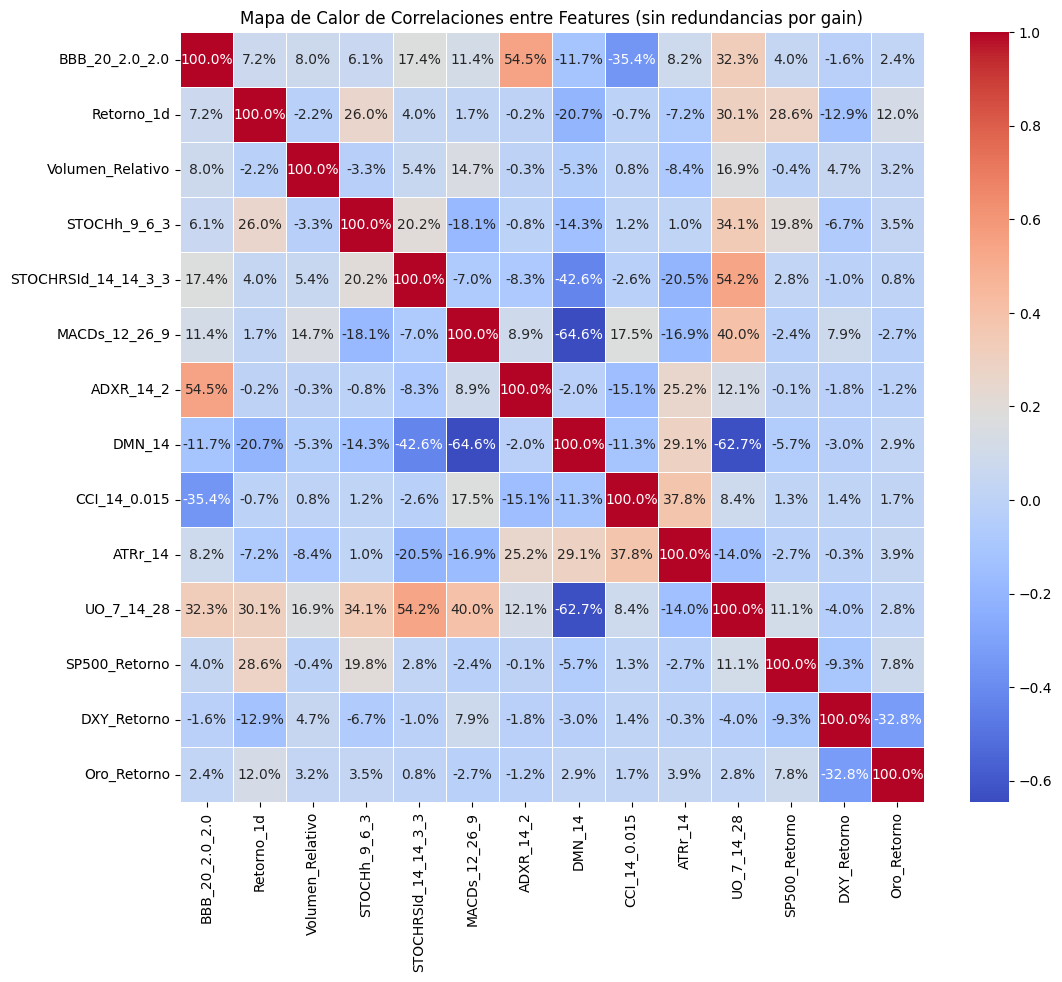

In [38]:
# Correlación entre variables depurando las redundantes
plt.figure(figsize=(12, 10))
sns.heatmap(features_df_std[high_gain_no_redundant].corr('spearman'), annot=True, fmt=".1%", cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones entre Features (sin redundancias por gain)")
plt.show()

In [40]:
print(f"Total variables seleccionadas por correlación y gain: {len(high_target_corr_no_redundant)}, {len(high_gain_no_redundant)}")

Total variables seleccionadas por correlación y gain: 13, 14


# Optimización bayesiana
---

## Funciones

In [58]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
import numpy as np

# Función Objetivo que Hyperopt intentará "Minimizar"
def objective_model(params, X_train_data, y_train_data, X_test_data, y_test_data):
    # Hyperopt con quniform devuelve floats, XGBoost exige enteros en estos campos
    max_depth = int(params['max_depth'])
    n_estimators = int(params['n_estimators'])
    umbral = params['umbral']

    modelo_tuning = xgb.XGBClassifier(
        max_depth=max_depth,
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        gamma=params['gamma'],
        n_estimators=n_estimators,
        scale_pos_weight=params['scale_pos_weight'],
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    # Entrenamos pasándole el conjunto de prueba para el Early Stopping
    modelo_tuning.fit(
        X_train_data, y_train_data,
        eval_set=[(X_test_data, y_test_data)],
        verbose=False
    )
    
    # Predecimos probabilidades
    probabilidades = modelo_tuning.predict_proba(X_test_data)
    y_pred_tuning = np.zeros(len(y_test_data))
    
    # Encontramos qué columna de probabilidad corresponde al Mínimo y al Máximo
    idx_minimo = np.where(le.classes_ == -1)[0][0]
    idx_maximo = np.where(le.classes_ == 1)[0][0]

    # Aplicamos el umbral Bayesiano
    for j in range(len(probabilidades)):
        if probabilidades[j][idx_minimo] >= umbral:
            y_pred_tuning[j] = -1
        elif probabilidades[j][idx_maximo] >= umbral:
            y_pred_tuning[j] = 1
            
    # Instanciamos el Backtester con parámetros de riesgo fijos (por ahora)
    bt_temp = tbt.Backtester(df_test_completo, capital_inicial=1000.0)
    retorno, _ = bt_temp.backtest_con_trailing_stop(
        predicciones=y_pred_tuning,
        tamaño_posicion=0.30, 
        stop_loss_inicial=0.03, 
        trailing_activation=0.03, 
        trailing_distancia=0.015
    )

    # Hyperopt minimiza, por lo que devolvemos el retorno negativo
    return {'loss': -retorno, 'status': STATUS_OK}


In [93]:
# Preprocesamiento probabilidades
def preprocesar_probabilidades(parametros, le, X_train_data, y_train_data, X_test_data):
    campeon_max_depth = int(parametros['max_depth'])
    campeon_n_estimators = int(parametros['n_estimators'])
    campeon_umbral = parametros['umbral']

    # 1. Entrenamos al campeón definitivo
    modelo_definitivo = xgb.XGBClassifier(
        max_depth=campeon_max_depth,
        learning_rate=parametros['learning_rate'],
        subsample=parametros['subsample'],
        gamma=parametros['gamma'],
        n_estimators=campeon_n_estimators,
        scale_pos_weight=parametros['scale_pos_weight'],
        random_state=42,
        n_jobs=-1
    )

    modelo_definitivo.fit(X_train_data, y_train_data)
    probabilidades_definitivas = modelo_definitivo.predict_proba(X_test_data)

    y_pred_fijo = np.zeros(len(X_test_data))

    # Encontramos qué columna de probabilidad corresponde al Mínimo y al Máximo
    idx_minimo = np.where(le.classes_ == -1)[0][0]
    idx_maximo = np.where(le.classes_ == 1)[0][0]

    for j in range(len(probabilidades_definitivas)):
        if probabilidades_definitivas[j][idx_minimo] >= campeon_umbral:
            y_pred_fijo[j] = -1
        elif probabilidades_definitivas[j][idx_maximo] >= campeon_umbral:
            y_pred_fijo[j] = 1
    
    return y_pred_fijo

In [75]:
# 3. Función Objetivo del Escudo
def objective_shield(params, proba):
    # Filtro lógico de protección
    if params['trailing_distancia'] >= params['trailing_activation']:
        return {'loss': 0, 'status': STATUS_OK} # Penalizamos combinaciones imposibles
        
    bt_definitivo = tbt.Backtester(df_test_completo, capital_inicial=1000.0)
    retorno, _ = bt_definitivo.backtest_con_trailing_stop(
        predicciones=proba,
        tamaño_posicion=params['tamaño_posicion'],
        stop_loss_inicial=params['stop_loss_inicial'],
        trailing_activation=params['trailing_activation'],
        trailing_distancia=params['trailing_distancia'],
        graficar=False
    )
    return {'loss': -retorno, 'status': STATUS_OK}

## Optimización del modelo con todas las features

In [59]:
print("--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (TODAS LAS FEATURES) ---")

# 1. Definimos el espacio de búsqueda Bayesiano para XGBoost
space_modelo = {
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', -6, -2),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 50),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'umbral': hp.quniform('umbral', 0.20, 0.35, 0.05),
}

# 2. Ejecutamos la búsqueda
trials_modelo = Trials()

mejores_parametros_modelo = fmin(
    fn=lambda params: objective_model(params, X_train, y_train_xgb, X_test, y_test_xgb),
    space=space_modelo,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_modelo,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (MODELO - TODAS LAS FEATURES):")
print(mejores_parametros_modelo)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (TODAS LAS FEATURES) ---
--- RESULTADOS DEL BACKTEST ---                       
Capital Inicial: $1000.00 USD                         
Capital Final: $1051.08 USD                           
Retorno Total: 5.11%                                  
Total de operaciones cerradas: 8                      
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1004.24 USD                                                     
Retorno Total: 0.42%                                                            
Total de operaciones cerradas: 16                                               
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $995.91 USD                                                      
Reto

## Optimización del modelo con selección por correlación del target

In [60]:
print("--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR CORRELACIÓN) ---")

# Preparar datos con features seleccionadas
X_train_sel = X_train[high_target_corr_no_redundant]
X_test_sel = X_test[high_target_corr_no_redundant]

# 1. Definimos el espacio de búsqueda Bayesiano para XGBoost
space_modelo_sel = {
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', -6, -2),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 50),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'umbral': hp.quniform('umbral', 0.20, 0.35, 0.05),
}

# 2. Ejecutamos la búsqueda
trials_modelo_sel = Trials()

mejores_parametros_modelo_sel = fmin(
    fn=lambda params: objective_model(params, X_train_sel, y_train_xgb, X_test_sel, y_test_xgb),
    space=space_modelo_sel,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_modelo_sel,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (MODELO - SELECCIÓN POR CORRELACIÓN):")
print(mejores_parametros_modelo_sel)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR CORRELACIÓN) ---
--- RESULTADOS DEL BACKTEST ---                       
Capital Inicial: $1000.00 USD                         
Capital Final: $1041.02 USD                           
Retorno Total: 4.10%                                  
Total de operaciones cerradas: 9                      
--- RESULTADOS DEL BACKTEST ---                                                  
Capital Inicial: $1000.00 USD                                                    
Capital Final: $1004.24 USD                                                      
Retorno Total: 0.42%                                                             
Total de operaciones cerradas: 16                                                
--- RESULTADOS DEL BACKTEST ---                                                  
Capital Inicial: $1000.00 USD                                                    
Capital Final: $981.84 USD                                             

## Optimización del modelo con selección por importancia

In [62]:
print("--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR IMPORTANCIA) ---")

# Preparar datos con features seleccionadas
X_train_gain = X_train[high_gain_no_redundant]
X_test_gain = X_test[high_gain_no_redundant]

# 1. Definimos el espacio de búsqueda Bayesiano para XGBoost
space_modelo_gain = {
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', -6, -2),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 50),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'umbral': hp.quniform('umbral', 0.20, 0.35, 0.05),
}

# 2. Ejecutamos la búsqueda
trials_modelo_gain = Trials()

mejores_parametros_modelo_gain = fmin(
    fn=lambda params: objective_model(params, X_train_gain, y_train_xgb, X_test_gain, y_test_xgb),
    space=space_modelo_gain,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_modelo_gain,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (MODELO - SELECCIÓN POR IMPORTANCIA):")
print(mejores_parametros_modelo_gain)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR IMPORTANCIA) ---
--- RESULTADOS DEL BACKTEST ---                       
Capital Inicial: $1000.00 USD                         
Capital Final: $981.34 USD                            
Retorno Total: -1.87%                                 
Total de operaciones cerradas: 4                      
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1004.24 USD                                                     
Retorno Total: 0.42%                                                            
Total de operaciones cerradas: 16                                               
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $992.75 USD                                                    

In [72]:
pd.DataFrame(
    {
        'Modelo': ['Todas las Features', 'Selección por Correlación', 'Selección por Importancia (Gain)'],
        'Mejor Retorno Backtest': [
            -min(trials_modelo.losses()), 
            -min(trials_modelo_sel.losses()), 
            -min(trials_modelo_gain.losses())
        ],
            'Mejores Parámetros': [
                mejores_parametros_modelo, 
                mejores_parametros_modelo_sel, 
                mejores_parametros_modelo_gain
            ]
    }
)


,Modelo,Mejor Retorno Backtest,Mejores Parámetros
0,Todas las Features,6.457489,"{'gamma': 0.11726609768193053, 'learning_rate'..."
1,Selección por Correlación,7.271433,"{'gamma': 0.12271133303676812, 'learning_rate'..."
2,Selección por Importancia (Gain),3.504018,"{'gamma': 0.21924560399188495, 'learning_rate'..."


## Optimización de la gestión del riesgo

In [ ]:
print("\n--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO ---")

# --- ¡IMPORTANTE! --- 
# Aquí debes reemplazar estos valores con los que te arroje el bloque 1
# (Hyperopt te devuelve los valores en un diccionario)
# --------------------
y_pred_final = preprocesar_probabilidades(mejores_parametros_modelo, le, X_train, y_train_xgb, X_test)

# 2. Definimos el espacio de búsqueda Bayesiano para el Escudo (Tus rangos exactos)
space_riesgo = {
    'tamaño_posicion': hp.quniform('tamaño_posicion', 0.10, 0.35, 0.05),
    'stop_loss_inicial': hp.quniform('stop_loss_inicial', 0.03, 0.10, 0.01),
    'trailing_activation': hp.quniform('trailing_activation', 0.03, 0.10, 0.01),
    'trailing_distancia': hp.quniform('trailing_distancia', 0.015, 0.05, 0.005)
}

# 4. Ejecutamos la búsqueda del Escudo
trials_riesgo = Trials()
mejores_parametros_riesgo = fmin(
    fn=lambda params: objective_shield(params, y_pred_final),
    space=space_riesgo,
    algo=tpe.suggest,
    max_evals=100, # Al ser un cálculo rápido sin entrenar modelo, podemos hacer 100 pruebas
    trials=trials_riesgo,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (ESCUDO):")
print(mejores_parametros_riesgo)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO ---
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                          
Capital Final: $972.46 USD                             
Retorno Total: -2.75%                                  
Total de operaciones cerradas: 5                       
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1017.37 USD                                                     
Retorno Total: 1.74%                                                            
Total de operaciones cerradas: 7                                                
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1012.78 USD                                                       
Retorno Total: 1.28%                  

## Optimización de la gestión del riesgo con selección por correlación

In [ ]:
print("\n--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR CORRELACIÓN) ---")


y_pred_sel = preprocesar_probabilidades(mejores_parametros_modelo_sel, le, X_train_sel, y_train_xgb, X_test_sel)

# 2. Definimos el espacio de búsqueda Bayesiano para el Escudo (Tus rangos exactos)
space_riesgo_sel = {
    'tamaño_posicion': hp.quniform('tamaño_posicion', 0.10, 0.35, 0.05),
    'stop_loss_inicial': hp.quniform('stop_loss_inicial', 0.03, 0.10, 0.01),
    'trailing_activation': hp.quniform('trailing_activation', 0.03, 0.10, 0.01),
    'trailing_distancia': hp.quniform('trailing_distancia', 0.015, 0.05, 0.005)
}

# 4. Ejecutamos la búsqueda del Escudo
trials_riesgo_sel = Trials()
mejores_parametros_riesgo_sel = fmin(
    fn=lambda params: objective_shield(params, y_pred_sel),
    space=space_riesgo_sel,
    algo=tpe.suggest,
    max_evals=100, # Al ser un cálculo rápido sin entrenar modelo, podemos hacer 100 pruebas
    trials=trials_riesgo_sel,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (ESCUDO):")
print(mejores_parametros_riesgo_sel)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR CORRELACIÓN) ---
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                          
Capital Final: $1002.26 USD                            
Retorno Total: 0.23%                                   
Total de operaciones cerradas: 5                       
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1023.55 USD                                                       
Retorno Total: 2.35%                                                              
Total de operaciones cerradas: 8                                                  
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1029.28 USD                               

## Optimización de la gestión del riesgo con selección por importancia

In [ ]:
print("\n--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR IMPORTANCIA) ---")


y_pred_gain = preprocesar_probabilidades(mejores_parametros_modelo_gain, le, X_train_gain, y_train_xgb, X_test_gain)

# 2. Definimos el espacio de búsqueda Bayesiano para el Escudo (Tus rangos exactos)
space_riesgo_gain = {
    'tamaño_posicion': hp.quniform('tamaño_posicion', 0.10, 0.35, 0.05),
    'stop_loss_inicial': hp.quniform('stop_loss_inicial', 0.03, 0.10, 0.01),
    'trailing_activation': hp.quniform('trailing_activation', 0.03, 0.10, 0.01),
    'trailing_distancia': hp.quniform('trailing_distancia', 0.015, 0.05, 0.005)
}

# 4. Ejecutamos la búsqueda del Escudo
trials_riesgo_gain = Trials()
mejores_parametros_riesgo_gain = fmin(
    fn=lambda params: objective_shield(params, y_pred_gain),
    space=space_riesgo_gain,
    algo=tpe.suggest,
    max_evals=100, # Al ser un cálculo rápido sin entrenar modelo, podemos hacer 100 pruebas
    trials=trials_riesgo_gain,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (ESCUDO):")
print(mejores_parametros_riesgo_gain)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR IMPORTANCIA) ---
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                          
Capital Final: $956.45 USD                             
Retorno Total: -4.36%                                  
Total de operaciones cerradas: 11                      
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1021.05 USD                                                     
Retorno Total: 2.11%                                                            
Total de operaciones cerradas: 16                                               
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1001.12 USD                                         

## Mejores parámetros
---

In [81]:
pd.DataFrame([mejores_parametros_modelo])

,gamma,learning_rate,max_depth,n_estimators,scale_pos_weight,subsample,umbral
0,0.117266,0.004573,4.0,300.0,4.15615,0.641233,0.25


In [82]:
pd.DataFrame([mejores_parametros_riesgo])

,stop_loss_inicial,tamaño_posicion,trailing_activation,trailing_distancia
0,0.03,0.35,0.03,0.015


--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $1075.50 USD
Retorno Total: 7.55%
Total de operaciones cerradas: 9


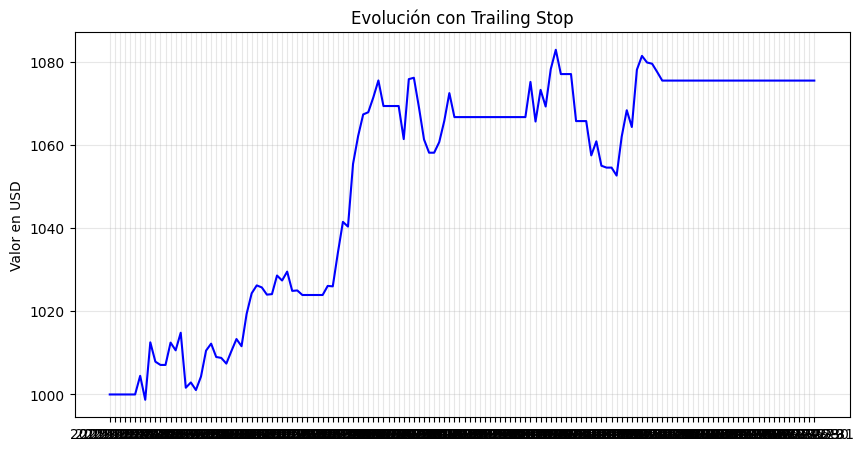

(np.float64(7.5499982933481995),
          Fecha                   Tipo         Precio      Capital
 0   2025-08-19                 Compra  112831.179688  1000.000000
 1   2025-08-24  Venta (Trailing Stop)  115120.974648  1007.102897
 2   2025-08-25                 Compra  110124.351562  1007.102897
 3   2025-09-21  Venta (Trailing Stop)  115380.145078  1023.925640
 4   2025-09-25                 Compra  109049.289062  1023.925640
 5   2025-10-07  Venta (Trailing Stop)  122881.243281  1069.382263
 6   2025-10-10                 Compra  113214.367188  1069.382263
 7   2025-10-16   Venta (Stop Inicial)  109817.936172  1058.153749
 8   2025-10-17                 Compra  106467.789062  1058.153749
 9   2025-10-21  Venta (Trailing Stop)  108930.095742  1066.719013
 10  2025-11-04                 Compra  101590.523438  1066.719013
 11  2025-11-11  Venta (Trailing Stop)  104406.644844  1077.068439
 12  2025-11-13                 Compra   99697.492188  1077.068439
 13  2025-11-14   Venta (Stop

In [83]:
tbt.Backtester(df_test_completo, capital_inicial=1000.0).backtest_con_trailing_stop(
        predicciones=y_pred_final,
        tamaño_posicion=mejores_parametros_riesgo['tamaño_posicion'],
        stop_loss_inicial=mejores_parametros_riesgo['stop_loss_inicial'],
        trailing_activation=mejores_parametros_riesgo['trailing_activation'],
        trailing_distancia=mejores_parametros_riesgo['trailing_distancia'],
        graficar=True
    )

In [84]:
X_test.index.values.min(), X_test.index.values.max()

('2025-08-14', '2025-12-31')

# Out-of-time validation
---

### Carga de datos OOT

In [87]:
# Cargamos los datos desde la carpeta data y si no existen, ejecutamos el pipeline
try: 
    os.chdir('..')
    os.chdir('data/processed')
    df_oot = pd.read_csv('btc_data_oot.csv', index_col=0)
    print("Datos cargados desde 'data/processed/btc_data_oot.csv'")

except FileNotFoundError:
    print("Archivo no encontrado. Ejecutando el pipeline para generar los datos...")

    # 1. Instanciar la clase (Configuramos las variables globales del proceso)
    extractor = btc_etl.BTC_DataExtractor(
        fecha_inicio="2026-01-01", 
        fecha_fin="2026-03-26", 
        ventana_critica=5
    )

    # 2. Ejecutar las transformaciones en cadena (Pipeline)
    # Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

    # Paso A: Obtener el precio histórico y volumen
    df_base = extractor.obtener_datos_btc()

    # Paso B: Etiquetar máximos y mínimos (Nuestro Target)
    df_etiquetado = extractor.etiquetar_puntos_criticos(df_base)

    # Paso C: Calcular todo el análisis técnico
    df_con_indicadores = extractor.agregar_indicadores_avanzados(df_etiquetado)

    # Paso D: Enriquecer con datos macroeconómicos
    df_oot = extractor.agregar_contexto_macro(df_con_indicadores)

    # 3. Revisar el resultado final
    print("\n--- Vista previa de las primeras 5 filas ---")
    print(df_oot.head())

    # Creamos el archivo en la carpeta data/processed
    os.chdir(CURRENT_DIR)
    os.chdir('..')
    os.makedirs('data/processed', exist_ok=True)
    df_oot.to_csv('data/processed/btc_data_oot.csv', index=True)
    
    print("Datos generados y guardados en 'data/processed/btc_data_oot.csv'")

finally:
    os.chdir(CURRENT_DIR) 


Archivo no encontrado. Ejecutando el pipeline para generar los datos...
Descargando datos de BTC-USD desde 2026-01-01...


[*********************100%***********************]  1 of 1 completed


Iniciando descarga de datos macroeconómicos...
-> Descargando SP500 (^GSPC)...
-> Descargando DXY (DX-Y.NYB)...
-> Descargando Oro (GC=F)...

¡Contexto macro agregado exitosamente!

--- Vista previa de las primeras 5 filas ---
                    Open          High           Low         Close  \
Date                                                                 
2026-02-04  75640.093750  76864.656250  71779.929688  73019.703125   
2026-02-05  73016.375000  73161.554688  62353.535156  62702.097656   
2026-02-06  62704.453125  71681.304688  60074.203125  70555.390625   
2026-02-07  70553.796875  71611.148438  67364.445312  69281.968750   
2026-02-08  69283.726562  72206.906250  68852.898438  70264.726562   

                  Volume  Retorno_Log  Target     RSI_14  BBL_20_2.0_2.0  \
Date                                                                       
2026-02-04   67215363944    -0.035171       0  25.831685    73236.586931   
2026-02-05  125509410908    -0.152334       0  17.8822

### Backtesting

In [88]:
df_oot.index.values.min(), df_oot.index.values.max()

(np.datetime64('2026-02-04T00:00:00.000000000'),
 np.datetime64('2026-03-25T00:00:00.000000000'))

3. Generando predicciones con el modelo campeón...
   -> Señales generadas: 9 alertas detectadas.
4. Ejecutando Backtester con Gestión de Riesgo Óptima...
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $973.69 USD
Retorno Total: -2.63%
Total de operaciones cerradas: 4


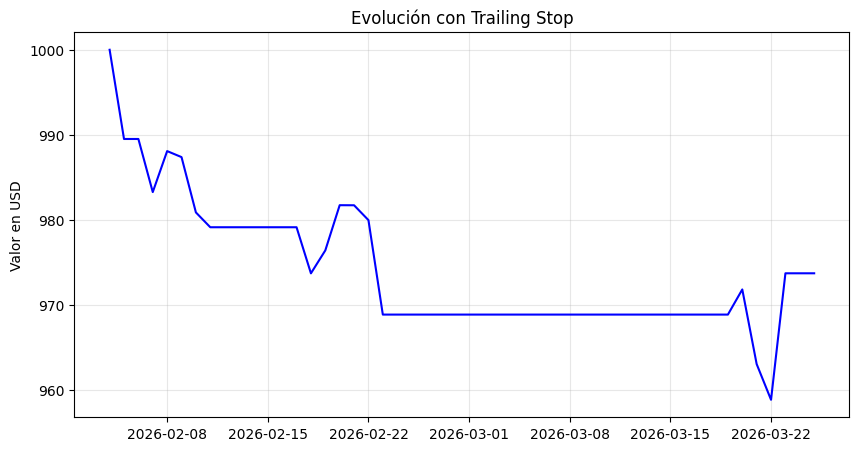


Historial de Operaciones en el OOT:
       Fecha                  Tipo        Precio      Capital
0 2026-02-04                Compra  73019.703125  1000.000000
1 2026-02-05  Venta (Stop Inicial)  70829.112031   989.500000
2 2026-02-06                Compra  70555.390625   989.500000
3 2026-02-11  Venta (Stop Inicial)  68438.728906   979.110250
4 2026-02-17                Compra  67494.218750   979.110250
5 2026-02-23  Venta (Stop Inicial)  65469.392188   968.829592
6 2026-03-19                Compra  69912.789062   968.829592
7 2026-03-23  Venta (Señal Modelo)  70914.859375   973.689824


In [ ]:
X_oot = df_oot[features]

# --- 3. PREDICCIÓN A CIEGAS ---
print("3. Generando predicciones con el modelo campeón...")

y_pred_oot = preprocesar_probabilidades(mejores_parametros_modelo, le, X_train, y_train_xgb, X_oot)

print(f"   -> Señales generadas: {np.sum(y_pred_oot != 0)} alertas detectadas.")

# --- 4. BACKTESTING FINAL ---
print("4. Ejecutando Backtester con Gestión de Riesgo Óptima...")
bt_oot = tbt.Backtester(df_oot, capital_inicial=1000.0)

retorno_oot, trades_oot = bt_oot.backtest_con_trailing_stop(
    predicciones=y_pred_oot,
    tamaño_posicion=mejores_parametros_riesgo['tamaño_posicion'],        # ¡El 35% dictado por Hyperopt!
    stop_loss_inicial=mejores_parametros_riesgo['stop_loss_inicial'],      # 3%
    trailing_activation=mejores_parametros_riesgo['trailing_activation'],    # 3%
    trailing_distancia=mejores_parametros_riesgo['trailing_distancia'],    # 1.5%
    graficar=True                # Queremos ver la curva de capital final
)

# Opcional: Mostrar los trades si hubo operaciones
if not trades_oot.empty:
    print("\nHistorial de Operaciones en el OOT:")
    print(trades_oot[['Fecha', 'Tipo', 'Precio', 'Capital']])

3. Generando predicciones con el modelo campeón...
   -> Señales generadas: 2 alertas detectadas.
4. Ejecutando Backtester con Gestión de Riesgo Óptima...
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $1032.02 USD
Retorno Total: 3.20%
Total de operaciones cerradas: 1


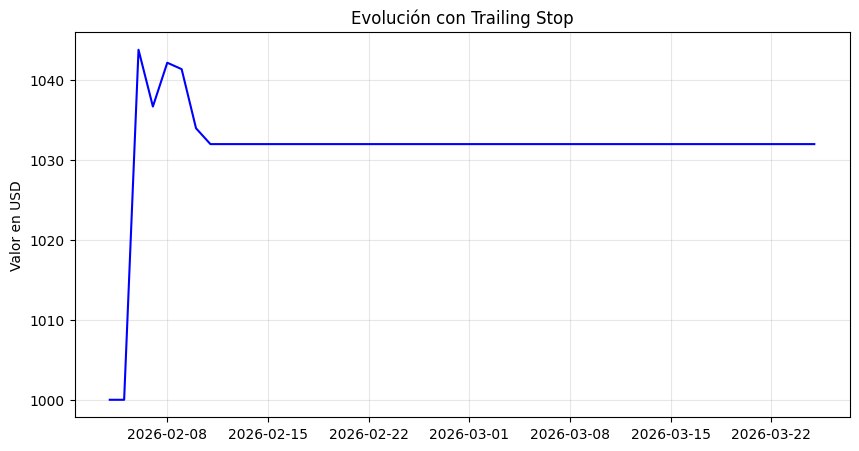


Historial de Operaciones en el OOT:
       Fecha                   Tipo        Precio      Capital
0 2026-02-05                 Compra  62702.097656  1000.000000
1 2026-02-11  Venta (Trailing Stop)  68438.728906  1032.021591


In [95]:
X_oot_sel = df_oot[high_target_corr_no_redundant]

# --- 3. PREDICCIÓN A CIEGAS ---
print("3. Generando predicciones con el modelo campeón...")

y_pred_oot_sel = preprocesar_probabilidades(mejores_parametros_modelo_sel, le, X_train_sel, y_train_xgb, X_oot_sel)

print(f"   -> Señales generadas: {np.sum(y_pred_oot_sel != 0)} alertas detectadas.")

# --- 4. BACKTESTING FINAL ---
print("4. Ejecutando Backtester con Gestión de Riesgo Óptima...")
bt_oot_sel = tbt.Backtester(df_oot, capital_inicial=1000.0)

retorno_oot_sel, trades_oot_sel = bt_oot_sel.backtest_con_trailing_stop(
    predicciones=y_pred_oot_sel,
    tamaño_posicion=mejores_parametros_riesgo_sel['tamaño_posicion'],        # ¡El 35% dictado por Hyperopt!
    stop_loss_inicial=mejores_parametros_riesgo_sel['stop_loss_inicial'],      # 3%
    trailing_activation=mejores_parametros_riesgo_sel['trailing_activation'],    # 3%
    trailing_distancia=mejores_parametros_riesgo_sel['trailing_distancia'],    # 1.5%
    graficar=True                # Queremos ver la curva de capital final
)

# Opcional: Mostrar los trades si hubo operaciones
if not trades_oot_sel.empty:
    print("\nHistorial de Operaciones en el OOT:")
    print(trades_oot_sel[['Fecha', 'Tipo', 'Precio', 'Capital']])

3. Generando predicciones con el modelo campeón...
   -> Señales generadas: 30 alertas detectadas.
4. Ejecutando Backtester con Gestión de Riesgo Óptima...
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $1022.01 USD
Retorno Total: 2.20%
Total de operaciones cerradas: 6


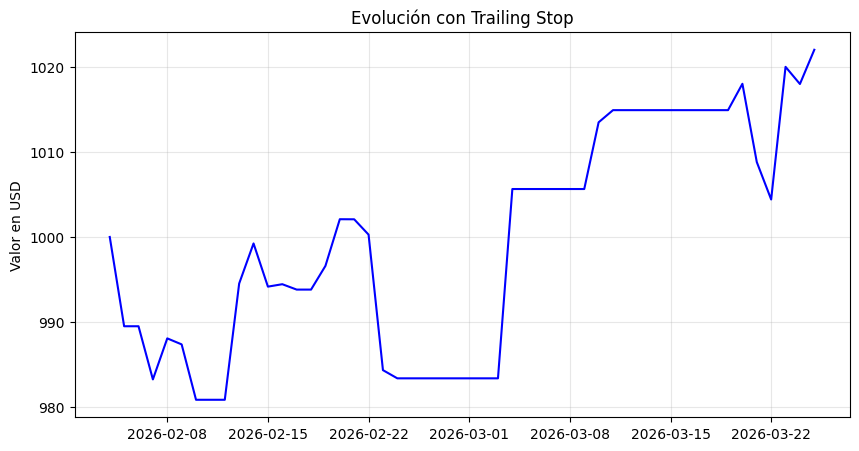


Historial de Operaciones en el OOT:
        Fecha                   Tipo        Precio      Capital
0  2026-02-04                 Compra  73019.703125  1000.000000
1  2026-02-05   Venta (Stop Inicial)  70829.112031   989.500000
2  2026-02-06                 Compra  70555.390625   989.500000
3  2026-02-10   Venta (Señal Modelo)  68793.960938   980.853926
4  2026-02-12                 Compra  66221.843750   980.853926
5  2026-02-17  Venta (Trailing Stop)  68721.110625   993.810308
6  2026-02-18                 Compra  66425.320312   993.810308
7  2026-02-24   Venta (Stop Inicial)  64432.560703   983.375300
8  2026-03-03                 Compra  68293.648438   983.375300
9  2026-03-04   Venta (Señal Modelo)  72710.578125  1005.635420
10 2026-03-09                 Compra  68402.382812  1005.635420
11 2026-03-11   Venta (Señal Modelo)  70204.882812  1014.910393
12 2026-03-19                 Compra  69912.789062  1014.910393


In [96]:
X_oot_g = df_oot[high_gain_no_redundant]

# --- 3. PREDICCIÓN A CIEGAS ---
print("3. Generando predicciones con el modelo campeón...")

y_pred_oot_g = preprocesar_probabilidades(mejores_parametros_modelo_gain, le, X_train_gain, y_train_xgb, X_oot_g)

print(f"   -> Señales generadas: {np.sum(y_pred_oot_g != 0)} alertas detectadas.")

# --- 4. BACKTESTING FINAL ---
print("4. Ejecutando Backtester con Gestión de Riesgo Óptima...")
bt_oot_g = tbt.Backtester(df_oot, capital_inicial=1000.0)

retorno_oot_g, trades_oot_g = bt_oot_g.backtest_con_trailing_stop(
    predicciones=y_pred_oot_g,
    tamaño_posicion=mejores_parametros_riesgo_gain['tamaño_posicion'],        # ¡El 35% dictado por Hyperopt!
    stop_loss_inicial=mejores_parametros_riesgo_gain['stop_loss_inicial'],      # 3%
    trailing_activation=mejores_parametros_riesgo_gain['trailing_activation'],    # 3%
    trailing_distancia=mejores_parametros_riesgo_gain['trailing_distancia'],    # 1.5%
    graficar=True                # Queremos ver la curva de capital final
)

# Opcional: Mostrar los trades si hubo operaciones
if not trades_oot_g.empty:
    print("\nHistorial de Operaciones en el OOT:")
    print(trades_oot_g[['Fecha', 'Tipo', 'Precio', 'Capital']])